In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

Load data


In [8]:
df_main = pd.read_csv("D:\\ITC\\YEAR 4\\semester 2\\data engineer\\TP\\data-engineer-constellation\\projects\\I4S2-TP08-sales-analysis-project\\data\\Retail_Transactions_Dataset.csv")
df = df_main.copy()

In [10]:
df.head(10)

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items
5,1000000005,2021-10-07 12:37:26,Joshua Frazier,"['Toothpaste', 'Chicken']",3,72.24,Cash,Houston,Supermarket,True,Retiree,Spring,Discount on Selected Items
6,1000000006,2023-01-08 10:40:03,Victoria Garrett,"['Honey', 'BBQ Sauce', 'Soda', 'Olive Oil', 'G...",4,5.28,Cash,Boston,Specialty Store,False,Student,Summer,Discount on Selected Items
7,1000000007,2020-09-03 12:39:59,Sydney Waller,"['Syrup', 'Trash Cans', 'Pancake Mix', 'Water'...",5,21.77,Debit Card,Chicago,Specialty Store,False,Young Adult,Winter,Discount on Selected Items
8,1000000008,2021-04-05 06:32:18,Kimberly Morgan,['Insect Repellent'],4,55.25,Mobile Payment,Los Angeles,Warehouse Club,False,Homemaker,Fall,NaN
9,1000000009,2021-07-08 10:08:59,Lori Conway,"['Soap', 'Baby Wipes', 'Soda']",7,31.21,Mobile Payment,Boston,Convenience Store,True,Young Adult,Winter,NaN


data cleaning

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Transaction_ID            0
Date                      0
Customer_Name             0
Product                   0
Total_Items               0
Total_Cost                0
Payment_Method            0
City                      0
Store_Type                0
Discount_Applied          0
Customer_Category         0
Season                    0
Promotion            333943
dtype: int64


In [7]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


Drop unwanted column

In [11]:
df = df.drop(columns=['Discount_Applied', 'Promotion'])

In [ ]:
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Customer_Category,Season
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,Homemaker,Winter
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,Professional,Fall
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,Professional,Winter
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,Homemaker,Spring
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,Young Adult,Winter


check data type and convert to its supposed data type

In [17]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].dtype)

datetime64[ns]


total sales

In [37]:
total_sales = df["Total_Cost"].sum()
print("Total Sales:", total_sales)

Total Sales: 52455220.400000006


top selling store

In [38]:
top_store = (
    df.groupby("Store_Type")["Total_Cost"]
    .sum()
    .reset_index()
)

top_store = top_store.sort_values(
    by="Total_Cost",
    ascending=False
)

print(top_store)

          Store_Type  Total_Cost
2           Pharmacy  8766679.01
4        Supermarket  8763455.21
5     Warehouse Club  8760029.03
0  Convenience Store  8731901.36
1   Department Store  8731555.57
3    Specialty Store  8701600.22


average sales

In [39]:
average_sales = df["Total_Cost"].mean()

print("Average Sales:", average_sales)

Average Sales: 52.45522040000001


## More analytics

Monthly Sale Trend

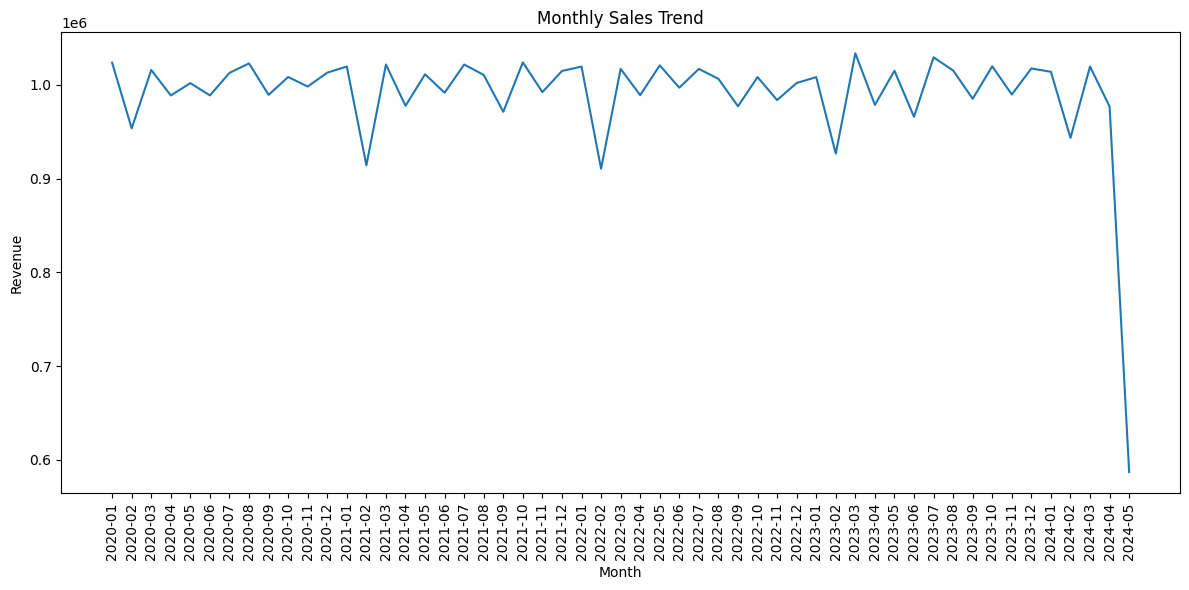

In [31]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Total_Cost"]
    .sum()
    .reset_index()
)

monthly_sales["Date"] = monthly_sales["Date"].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales["Date"], monthly_sales["Total_Cost"])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


Top 10 Product

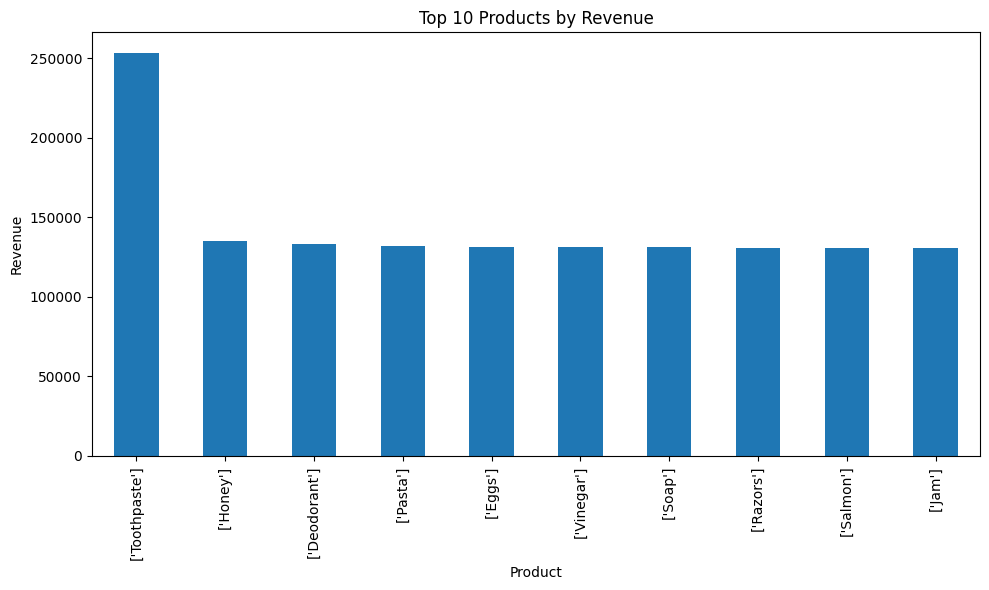

In [21]:
top_products = (
    df.groupby("Product")["Total_Cost"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

revenue by city

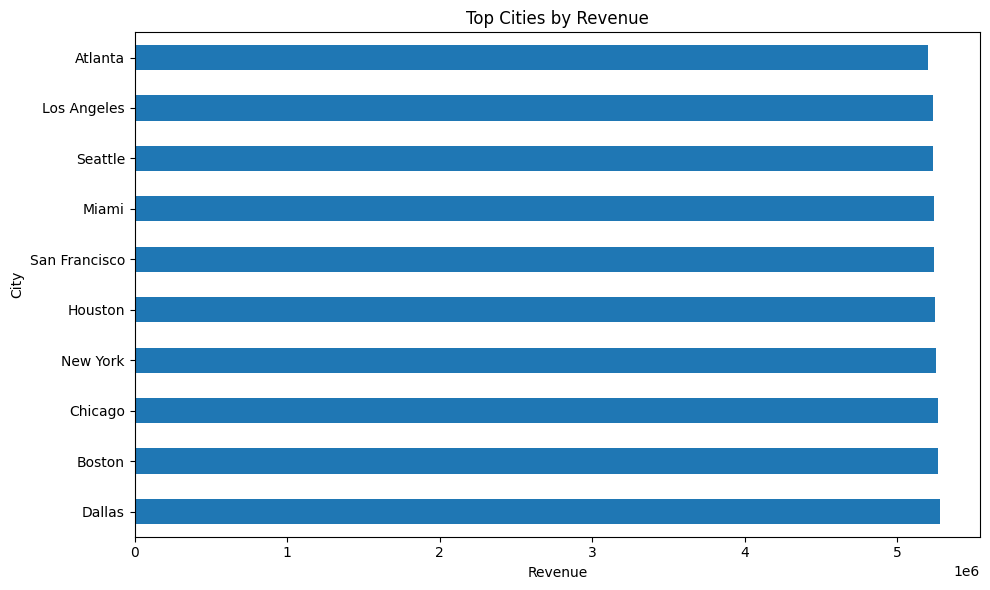

In [22]:
city_sales = (
    df.groupby("City")["Total_Cost"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
city_sales.plot(kind="barh")

plt.title("Top Cities by Revenue")
plt.xlabel("Revenue")

plt.tight_layout()
plt.show()

Paymennt Method

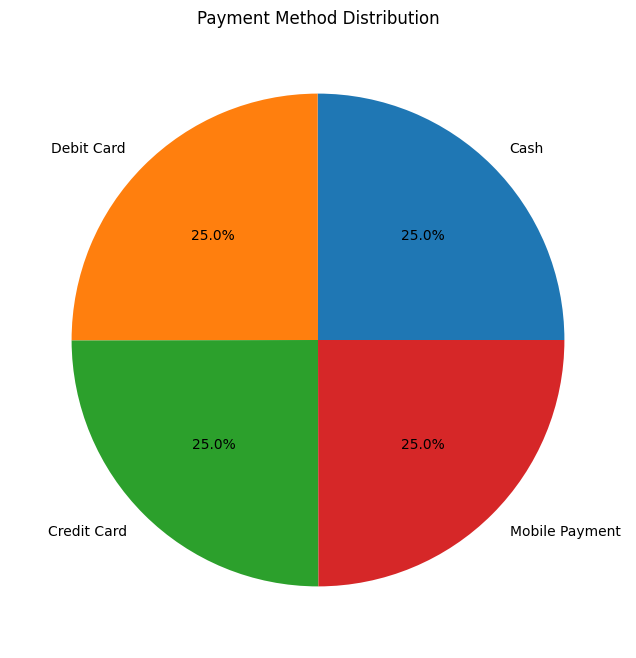

In [23]:
payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(8,8))
payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.show()

seasonal sales

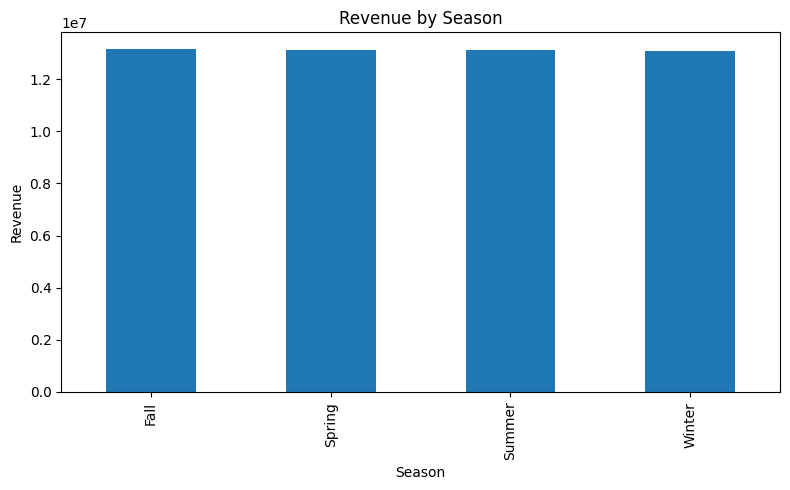

In [24]:
season_sales = (
    df.groupby("Season")["Total_Cost"]
    .sum()
)

plt.figure(figsize=(8,5))
season_sales.plot(kind="bar")

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

total item vs total cost

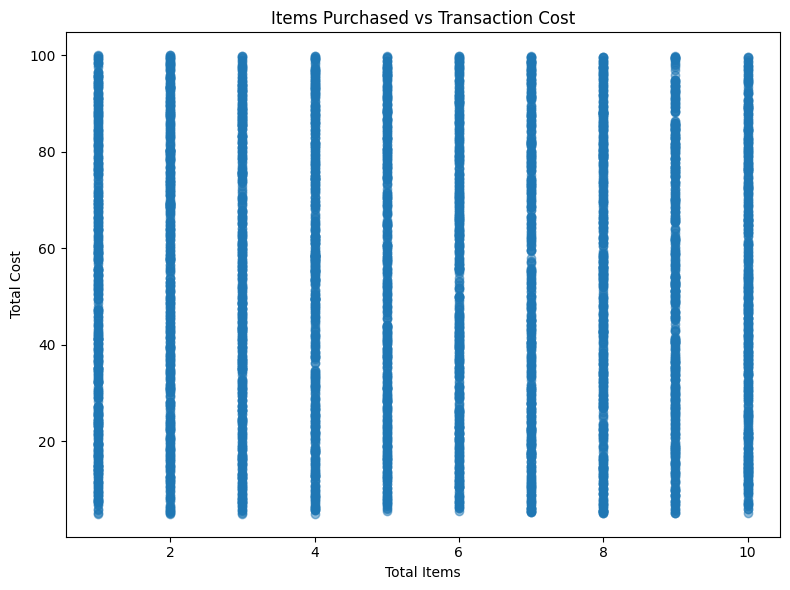

In [25]:
sample = df.sample(5000)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["Total_Items"],
    sample["Total_Cost"],
    alpha=0.5
)

plt.title("Items Purchased vs Transaction Cost")
plt.xlabel("Total Items")
plt.ylabel("Total Cost")

plt.tight_layout()
plt.show()

customer gategory analysis

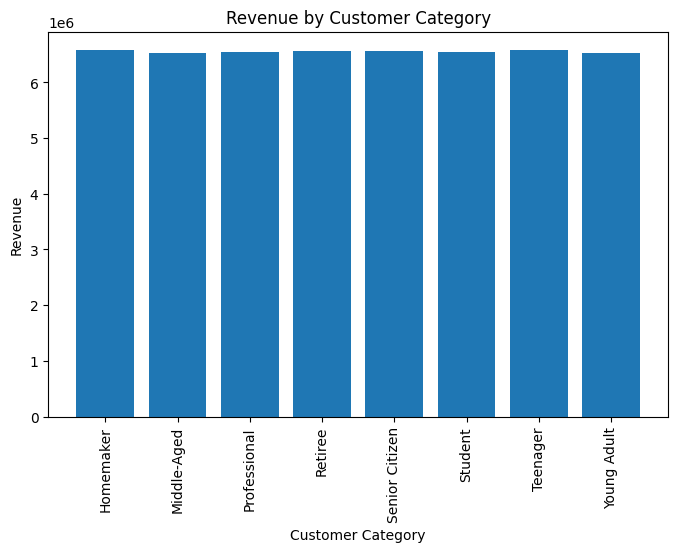

In [32]:
customer_sales = (
    df.groupby("Customer_Category")["Total_Cost"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    customer_sales["Customer_Category"],
    customer_sales["Total_Cost"]
)

plt.title("Revenue by Customer Category")
plt.xlabel("Customer Category")
plt.xticks(rotation=90)

plt.ylabel("Revenue")

plt.show()

customer product preferences (grouped by top 5 products)

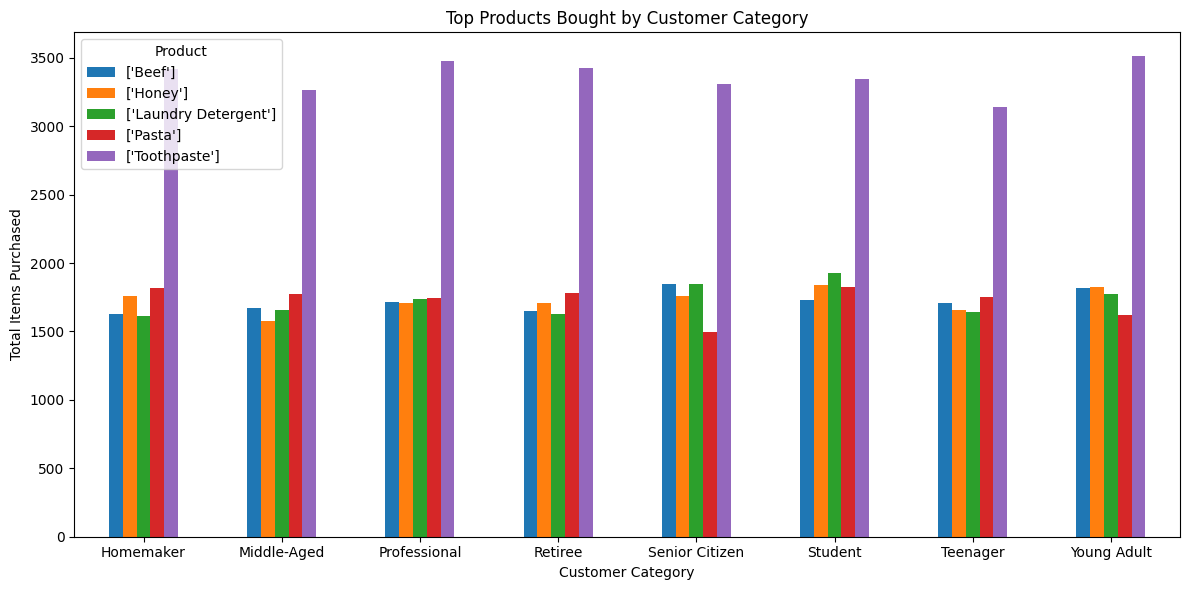

In [36]:
product_customer = (
    df.groupby(
        ["Customer_Category", "Product"]
    )["Total_Items"]
    .sum()
    .reset_index()
)


product_customer = product_customer[
    product_customer["Product"].isin(top_products)
]

pivot_table = product_customer.pivot_table(
    index="Customer_Category",
    columns="Product",
    values="Total_Items",
    fill_value=0
)

pivot_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top Products Bought by Customer Category")
plt.xlabel("Customer Category")
plt.ylabel("Total Items Purchased")

plt.xticks(rotation=0)

plt.legend(title="Product")

plt.tight_layout()
plt.show()